In [1]:
import pandas as pd

df = pd.DataFrame()
for i in range(127):
    captions = f'/data3/lihaochen/datasets/CosmicManHQ-1.0/label/laion1B-nolang_{i}_human.parquet'
    df_split = pd.read_parquet(captions, columns=['image_name', 'blip_text'])
    df = pd.concat([df, df_split], ignore_index=True)

df['image_name'] = df['image_name'].apply(lambda x: int(x.split('.')[0]))
df.set_index('image_name', inplace=True)

In [2]:
import os
import datasets
import pandas as pd
import tqdm

dataset_root = '/data/lihaochen/datasets/BGRelight/imgs'
dataset = []

for img_dir_split in range(5):
    img_dir = os.path.join(dataset_root, '%05d' % img_dir_split)
    img_files = os.listdir(img_dir)
    img_files = sorted(img_files)
    
    exist = 0
    not_exist = 0

    for i, img_file in tqdm.tqdm(enumerate(img_files)):
        img_path = os.path.join(img_dir, img_file)
        person = f'{img_dir_split}/{img_file}'
        phi = 0
        mask = os.path.join(img_path, 'mask.png')
        source = os.path.join(img_path, 'relight.png')
        target = os.path.join(img_path, 'base.png')
        img_depth = os.path.join(img_path, 'img_depth.npy')
        bg_depth = os.path.join(img_path, 'bg_depth.npy')
        lighting = os.path.join(img_path, 'hdr', 'refined.exr')
        bg = os.path.join(img_path, 'inpainted.png')
        fused_depth = os.path.join(img_path, 'fused_depth.npy')
        if not os.path.exists(img_depth):
            continue
        if not os.path.exists(source):
            continue
        if int(img_file) in df.index:
            caption = df.loc[int(img_file)]['blip_text']
            exist += 1
        else:
            caption = ''
            not_exist += 1
            # print(f'{img_file} not exist')
        dataset.append((person, phi, mask, source, target, img_depth, bg_depth, caption, lighting, bg, fused_depth))

    print(f'exist: {exist}, not exist: {not_exist}')

dict_dataset = {
    'person': [r[0] for r in dataset],
    'phi': [r[1] for r in dataset],
    'mask': [r[2] for r in dataset],
    'source': [r[3] for r in dataset],
    'target': [r[4] for r in dataset],
    'img_depth': [r[5] for r in dataset],
    'bg_depth': [r[6] for r in dataset],
    'caption': [r[7] for r in dataset],
    'lighting': [r[8] for r in dataset],
    'bg': [r[9] for r in dataset],
    'fused_depth': [r[10] for r in dataset],
}

ds = datasets.Dataset.from_dict(dict_dataset)
ds = ds.train_test_split(test_size=0.1, seed=42)

ds

ds['train'].to_parquet('./stage2_train.parquet')
ds['test'].to_parquet('./stage2_test.parquet')

/data1/lihaochen/envs/relight/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
1122it [00:02, 414.99it/s]


exist: 1068, not exist: 6


1309it [00:02, 507.30it/s]


exist: 1244, not exist: 16


1287it [00:03, 350.79it/s]


...

exist: 1065, not exist: 13


845it [00:02, 336.26it/s]


exist: 803, not exist: 7


Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 33.89ba/s]


378520

In [10]:
#fuse depth
import cv2
import os
import numpy as np
import tqdm

def adjust_and_fuse_depth(foreground_depth, background_depth, foreground_mask, bottom_rows=5):
    """
    将前景深度图与背景深度图融合，确保前景物体（如人）的脚部深度与背景一致。

    参数:
        foreground_depth (np.ndarray): 前景深度图。
        background_depth (np.ndarray): 背景深度图。
        foreground_mask (np.ndarray): 前景掩码，1表示前景，0表示背景。
        bottom_rows (int): 取前景物体底部的行数，默认为5。

    返回:
        np.ndarray: 融合后的深度图。
    """
    # 确保输入数组的尺寸一致
    assert foreground_depth.shape == background_depth.shape == foreground_mask.shape, "输入数组的尺寸必须一致"
    
    # 找到前景物体的底部区域（取底部多行）
    bottom_mask = np.zeros_like(foreground_mask, dtype=bool)
    rows, cols = np.where(foreground_mask == 1)  # 找到所有前景像素的行和列
    if len(rows) == 0:
        return background_depth  # 如果没有前景物体，直接返回背景深度图
    
    # 找到每一列的前景物体的最底部行
    unique_cols = np.unique(cols)  # 所有有前景物体的列
    for col in unique_cols:
        col_rows = rows[cols == col]  # 当前列的所有前景行
        if len(col_rows) > 0:
            bottom_row = np.max(col_rows)  # 当前列的最底部行
            # 取底部多行
            bottom_mask[col_rows[col_rows >= (bottom_row - bottom_rows + 1)], col] = True
    
    # 计算前景物体底部的平均深度
    foreground_bottom_depth = np.mean(foreground_depth[bottom_mask])
    
    # 计算背景对应区域的平均深度
    background_bottom_depth = np.mean(background_depth[bottom_mask])
    
    # 计算深度差异
    depth_diff = background_bottom_depth - foreground_bottom_depth
    
    # 调整前景物体的深度值
    adjusted_foreground_depth = foreground_depth.copy()
    adjusted_foreground_depth[foreground_mask == 1] += depth_diff
    
    # 将调整后的前景深度信息融合到背景深度图中
    fused_depth = background_depth.copy()
    fused_depth[foreground_mask == 1] = adjusted_foreground_depth[foreground_mask == 1]
    
    return fused_depth

dataset_root = '/data/lihaochen/datasets/BGRelight/imgs'
dataset = []

for img_dir_split in range(5):
    img_dir = os.path.join(dataset_root, '%05d' % img_dir_split)
    img_files = os.listdir(img_dir)
    img_files = sorted(img_files)
    
    exist = 0
    not_exist = 0

    for i, img_file in tqdm.tqdm(enumerate(img_files)):
        img_path = os.path.join(img_dir, img_file)
        mask = os.path.join(img_path, 'mask.png')
        img_depth = os.path.join(img_path, 'img_depth.npy')
        bg_depth = os.path.join(img_path, 'bg_depth.npy')
        fused_depth_path = os.path.join(img_path, 'fused_depth.npy')
        if not os.path.exists(img_depth):
            continue
        # if os.path.exists(fused_depth_path):
        #     continue
        img_depth = np.load(img_depth)
        if os.path.exists(fused_depth_path):
            tmp = np.load(fused_depth_path)
            if tmp.shape == img_depth.shape:
                continue
        mask = cv2.imread(mask, cv2.IMREAD_UNCHANGED)
        mask = np.where(mask > 0, 1, 0).astype(np.float32)
        bg_depth = np.load(bg_depth)
        fused_depth = adjust_and_fuse_depth(img_depth, bg_depth, mask)
        np.save(fused_depth_path, fused_depth)

0it [00:00, ?it/s]

1122it [01:04, 17.39it/s]
1309it [01:19, 16.38it/s] 
1287it [00:04, 299.56it/s]
1129it [00:03, 295.65it/s]
845it [00:03, 263.48it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [7.332978e-07..32.0].


torch.Size([3, 1024, 1024]) tensor(7.3330e-07) tensor(32.)


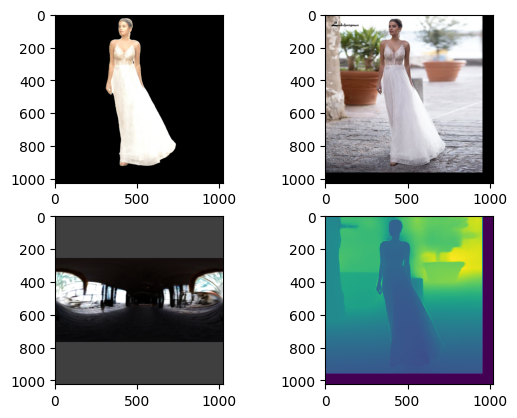

In [8]:
# dataset read test
import os
from datasets import load_dataset
from torchvision import transforms
from torchvision.transforms import v2
from torchvision.transforms.v2.functional import crop
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ds = load_dataset('parquet', data_files='./stage2_test.parquet')

os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1" 
os.environ["OPENCV_IMGCODECS_USE_OPENEXR"] = "1"

class TopCenterCrop:
    def __init__(self, resolution):
        self.resolution = resolution

    def __call__(self, img):
        _, height, width = img.shape  # 获取图像宽高
        if height > width:  # 竖图
            top = max(0, height // 4 - self.resolution // 2)  # 向上偏移裁剪
            left = max(0, (width - self.resolution) // 2)  # 水平居中裁剪
        else:  # 横图，保持中心裁剪
            top = max(0, (height - self.resolution) // 2)
            left = max(0, (width - self.resolution) // 2)

        return crop(img, top, left, self.resolution, self.resolution)

image_transforms = v2.Compose(
    [
        v2.Resize(1024, interpolation=v2.InterpolationMode.BILINEAR),
        v2.ToTensor(),
        TopCenterCrop(1024),
        v2.Normalize([0.5], [0.5]),
    ]
)

conditioning_image_transforms = v2.Compose(
    [
        v2.Resize(1024, interpolation=v2.InterpolationMode.BILINEAR),
        v2.ToTensor(),
        TopCenterCrop(1024),
    ]
)

bg_image_transforms = v2.Compose(
    [
        v2.ToTensor(),
        v2.Resize(size=512, max_size=1024, interpolation=v2.InterpolationMode.BILINEAR),
        v2.Pad([0, 256], fill=0.25, padding_mode='constant'),
    ]
)

def adjust_and_fuse_depth(foreground_depth, background_depth, foreground_mask, bottom_rows=5):
    """
    将前景深度图与背景深度图融合，确保前景物体（如人）的脚部深度与背景一致。

    参数:
        foreground_depth (np.ndarray): 前景深度图。
        background_depth (np.ndarray): 背景深度图。
        foreground_mask (np.ndarray): 前景掩码，1表示前景，0表示背景。
        bottom_rows (int): 取前景物体底部的行数，默认为5。

    返回:
        np.ndarray: 融合后的深度图。
    """
    # 确保输入数组的尺寸一致
    assert foreground_depth.shape == background_depth.shape == foreground_mask.shape, "输入数组的尺寸必须一致"
    
    # 找到前景物体的底部区域（取底部多行）
    bottom_mask = np.zeros_like(foreground_mask, dtype=bool)
    rows, cols = np.where(foreground_mask == 1)  # 找到所有前景像素的行和列
    if len(rows) == 0:
        return background_depth  # 如果没有前景物体，直接返回背景深度图
    
    # 找到每一列的前景物体的最底部行
    unique_cols = np.unique(cols)  # 所有有前景物体的列
    for col in unique_cols:
        col_rows = rows[cols == col]  # 当前列的所有前景行
        if len(col_rows) > 0:
            bottom_row = np.max(col_rows)  # 当前列的最底部行
            # 取底部多行
            bottom_mask[col_rows[col_rows >= (bottom_row - bottom_rows + 1)], col] = True
    
    # 计算前景物体底部的平均深度
    foreground_bottom_depth = np.mean(foreground_depth[bottom_mask])
    
    # 计算背景对应区域的平均深度
    background_bottom_depth = np.mean(background_depth[bottom_mask])
    
    # 计算深度差异
    depth_diff = background_bottom_depth - foreground_bottom_depth
    
    # 调整前景物体的深度值
    adjusted_foreground_depth = foreground_depth.copy()
    adjusted_foreground_depth[foreground_mask == 1] += depth_diff
    
    # 将调整后的前景深度信息融合到背景深度图中
    fused_depth = background_depth.copy()
    fused_depth[foreground_mask == 1] = adjusted_foreground_depth[foreground_mask == 1]
    
    return fused_depth

def poisson_blend(foreground, background, mask):
    # 计算融合中心点
    center = (background.shape[1] // 2, background.shape[0] // 2)
    # 使用泊松融合
    blended = cv2.seamlessClone(foreground, background, mask, center, cv2.NORMAL_CLONE)
    return blended

def preprocess_train(examples):
    source = [cv2.imread(source, cv2.IMREAD_UNCHANGED) for source in examples['source']]
    source = [cv2.cvtColor(s, cv2.COLOR_BGR2RGB) for s in source]
    source = [conditioning_image_transforms(s) for s in source]

    target = [cv2.imread(target, cv2.IMREAD_UNCHANGED) for target in examples['target']]
    target = [cv2.cvtColor(t, cv2.COLOR_BGR2RGB) for t in target]
    target = [image_transforms(t) for t in target]

    mask = [cv2.imread(mask, cv2.IMREAD_UNCHANGED) for mask in examples['mask']]
    mask = [np.where(m > 0, 1, 0).astype(np.float32) for m in mask]
    img_depth = [np.load(depth) for depth in examples['img_depth']]
    bg_depth = [np.load(depth) for depth in examples['bg_depth']]
    # depth = [adjust_and_fuse_depth(d1, d2, m) for m, d1, d2 in zip(mask, img_depth, bg_depth)]
    # depth = [poisson_blend(d1, d2, m) for m, d1, d2 in zip(mask, img_depth, bg_depth)]
    depth = [np.load(depth) for depth in examples['fused_depth']]
    
    mask = [np.expand_dims(m, axis=-1) for m in mask]
    mask = [conditioning_image_transforms(m) for m in mask]

    depth = [np.expand_dims(d, axis=-1) for d in depth]
    depth = [conditioning_image_transforms(d) for d in depth]

    lighting = [cv2.imread(lighting, cv2.IMREAD_UNCHANGED) for lighting in examples['lighting']]
    lighting = [cv2.cvtColor(l, cv2.COLOR_BGR2RGB) for l in lighting]
    lighting = [np.roll(l, l.shape[1] // 2, 1) for l in lighting]
    lighting = [bg_image_transforms(l) for l in lighting]

    # phi = [torch.tensor(phi) for phi in examples['phi']]

    examples['source'] = source
    examples['target'] = target
    examples['mask'] = mask
    examples['depth'] = depth
    examples['lighting'] = lighting
    
    return examples

ds = ds.with_transform(preprocess_train)
ds = ds['train']

# ds['train'][0]['lighting']
sample = ds[3]
plt.figure()
plt.subplot(2, 2, 1)
plt.imshow(sample['source'].permute(1, 2, 0))
# plt.imshow(ds['train'][idx]['source'])
plt.subplot(2, 2, 2)
plt.imshow(v2.functional.normalize(sample['target'], [-1.0], [2.0]).permute(1, 2, 0))
# plt.imshow(ds['train'][idx]['target'])
plt.subplot(2, 2, 3)
print(sample['lighting'].shape, sample['lighting'].min(), sample['lighting'].max())
plt.imshow(sample['lighting'].permute(1, 2, 0))
plt.subplot(2, 2, 4)
plt.imshow(sample['depth'].permute(1, 2, 0).squeeze())

plt.show()
